# MNIST Classification with TensorFlow (CNN)

A **convolutional neural network (CNN)** following the block structure:  
   `Input → Convolution → Max Pooling → Convolution → Dropout → Max Pooling → Convolution → Max Pooling → Linear → Linear → Output`

We will:

- Load and preprocess the MNIST data.
- Define the model architecture in TensorFlow.
- Specify the **loss function**, **optimizer**, and **metrics**.
- Implement an explicit **training loop** using `tf.GradientTape`.
- Track **training and validation loss and accuracy per epoch** and plot them.
- Run a **prediction example** on a test image and visualize both the image and the predicted probabilities.


In [26]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Make sure we're using TensorFlow 2.x in eager mode
print("TensorFlow version:", tf.__version__)

# 1) Load Fashion-MNIST

fmnist = tf.keras.datasets.fashion_mnist
(x_train_full, y_train_full), (x_test, y_test) = fmnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Train full:", x_train_full.shape, y_train_full.shape)
print("Test:", x_test.shape, y_test.shape)

TensorFlow version: 2.19.0
Train full: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


In [28]:
# 2) Normalize images to [0,1]
# Normalize images to [0, 1] by dividing by 255.0
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 3) Create validation split
x_train, x_val = x_train_full[:50000], x_train_full[50000:]
y_train, y_val = y_train_full[:50000], y_train_full[50000:]

print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)

# 4) Add channel dimension for CNN

# Add a channel dimension to each image so the shape is (28, 28, 1)
x_train_cnn = x_train[..., tf.newaxis]
x_val_cnn = x_val[..., tf.newaxis]
x_test_cnn = x_test[..., tf.newaxis]

print("CNN training data shape:", x_train_cnn.shape)

# 5) Build tf.data datasets

batch_size = 128
AUTOTUNE = tf.data.AUTOTUNE

train_ds_base = (
    tf.data.Dataset.from_tensor_slices((x_train_cnn, y_train))
    .shuffle(10000, seed=42)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((x_val_cnn, y_val))
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((x_test_cnn, y_test))
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

# 6) Data augmentation pipeline
#    Using at least 3 augmentations:
#    - random horizontal flip
#    - random rotation
#    - random zoom (acts similarly to random crop/rescale)
#    - random contrast
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.08),
        tf.keras.layers.RandomZoom(height_factor=(-0.10, 0.10), width_factor=(-0.10, 0.10)),
        tf.keras.layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

def augment_batch(images, labels):
    images = data_augmentation(images, training=True)
    return images, labels

train_ds_aug = (
    tf.data.Dataset.from_tensor_slices((x_train_cnn, y_train))
    .shuffle(10000, seed=42)
    .batch(batch_size)
    .map(augment_batch, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# ==============================================
# Shared helper: accuracy computation
# ==============================================

def accuracy_from_probs(probs, labels):
    # Compute accuracy from predicted probabilities and true labels.
    preds = tf.argmax(probs, axis=1, output_type=tf.int32)
    labels = tf.cast(labels, tf.int32)
    correct = tf.equal(preds, labels)
    return tf.reduce_mean(tf.cast(correct, tf.float32))


Training set: (50000, 28, 28) (50000,)
Validation set: (10000, 28, 28) (10000,)
Test set: (10000, 28, 28) (10000,)
CNN training data shape: (50000, 28, 28, 1)


In [29]:
# ===============================================
#  8) CNN model definition
#    Architecture outline:
#    Input -> Conv -> MaxPool -> Conv -> Dropout
#          -> MaxPool -> Conv -> MaxPool -> Dense -> Dense -> Output
# ===============================================

def build_cnn_model():
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(28, 28, 1), name="input_image"),

            # Block 1
            tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu", name="conv_1"),
            tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="maxpool_1"),

            # Block 2
            tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu", name="conv_2"),
            tf.keras.layers.Dropout(0.25, name="dropout_1"),
            tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="maxpool_2"),

            # Block 3
            tf.keras.layers.Conv2D(128, kernel_size=(3, 3), activation="relu", name="conv_3"),
            tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name="maxpool_3"),

            # Classifier
            tf.keras.layers.Flatten(name="flatten"),
            tf.keras.layers.Dense(128, activation="relu", name="dense_1"),
            tf.keras.layers.Dense(64, activation="relu", name="dense_2"),
            tf.keras.layers.Dense(10, activation="softmax", name="output_softmax"),
        ],
        name="CNN_FashionMNIST",
    )
    return model

# Show architecture summary once
temp_model = build_cnn_model()
temp_model.summary()

# 9) Training function

def run_experiment(train_ds, val_ds, epochs=10, learning_rate=1e-3, experiment_name="Experiment"):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    np.random.seed(42)

    model = build_cnn_model()
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    print(f"\n{'='*70}")
    print(f"{experiment_name}")
    print(f"{'='*70}")

    for epoch in range(1, epochs + 1):
        print(f"\n=== Epoch {epoch}/{epochs} ===")

        # -------------------------
        # Training phase
        # -------------------------
        train_losses = []
        train_accuracies = []

        for step, (x_batch, y_batch) in enumerate(train_ds):
            with tf.GradientTape() as tape:
                probs = model(x_batch, training=True)
                loss_value = loss_fn(y_batch, probs)

            grads = tape.gradient(loss_value, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            acc = accuracy_from_probs(probs, y_batch)
            train_losses.append(loss_value.numpy())
            train_accuracies.append(acc.numpy())

            if step % 100 == 0:
                print(f"  Step {step:03d} - Batch loss: {loss_value:.4f}, accuracy: {acc:.4f}")

        epoch_train_loss = np.mean(train_losses)
        epoch_train_acc = np.mean(train_accuracies)

        # -------------------------
        # Validation phase
        # -------------------------
        val_losses = []
        val_accuracies = []

        for x_batch_val, y_batch_val in val_ds:
            probs_val = model(x_batch_val, training=False)
            val_loss_value = loss_fn(y_batch_val, probs_val)
            val_acc = accuracy_from_probs(probs_val, y_batch_val)

            val_losses.append(val_loss_value.numpy())
            val_accuracies.append(val_acc.numpy())

        epoch_val_loss = np.mean(val_losses)
        epoch_val_acc = np.mean(val_accuracies)

        train_loss_history.append(epoch_train_loss)
        val_loss_history.append(epoch_val_loss)
        train_acc_history.append(epoch_train_acc)
        val_acc_history.append(epoch_val_acc)

        print(
            f"Epoch {epoch}: "
            f"Train loss = {epoch_train_loss:.4f}, Train acc = {epoch_train_acc:.4f} | "
            f"Val loss = {epoch_val_loss:.4f}, Val acc = {epoch_val_acc:.4f}"
        )

    results = {
        "model": model,
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "train_acc": train_acc_history,
        "val_acc": val_acc_history,
        "final_train_acc": train_acc_history[-1],
        "final_val_acc": val_acc_history[-1],
        "generalization_gap": train_acc_history[-1] - val_acc_history[-1],
    }
    return results



Model: "CNN_FashionMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_3 (MaxPooling2D)        │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Dense)          │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,090 (461.29 KB)

 Trainable params: 118,090 (461.29 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# 10) Run both experiments

epochs_cnn = 10
learning_rate = 1e-3

baseline_results = run_experiment(
    train_ds=train_ds_base,
    val_ds=val_ds,
    epochs=epochs_cnn,
    learning_rate=learning_rate,
    experiment_name="Experiment 1 — No Data Augmentation"
)

aug_results = run_experiment(
    train_ds=train_ds_aug,
    val_ds=val_ds,
    epochs=epochs_cnn,
    learning_rate=learning_rate,
    experiment_name="Experiment 2 — With Data Augmentation"
)



Experiment 1 — No Data Augmentation

=== Epoch 1/10 ===
  Step 000 - Batch loss: 2.3026, accuracy: 0.1250
  Step 100 - Batch loss: 2.3006, accuracy: 0.1172
  Step 200 - Batch loss: 2.3014, accuracy: 0.1562
  Step 300 - Batch loss: 2.3034, accuracy: 0.0625
Epoch 1: Train loss = 2.3028, Train acc = 0.0994 | Val loss = 2.3016, Val acc = 0.1004

=== Epoch 2/10 ===
  Step 000 - Batch loss: 2.3013, accuracy: 0.0938
  Step 100 - Batch loss: 1.5998, accuracy: 0.3125
  Step 200 - Batch loss: 1.2260, accuracy: 0.5469
  Step 300 - Batch loss: 1.3805, accuracy: 0.4844
Epoch 2: Train loss = 1.3977, Train acc = 0.4433 | Val loss = 1.0260, Val acc = 0.6059

=== Epoch 3/10 ===
  Step 000 - Batch loss: 0.9947, accuracy: 0.6328
  Step 100 - Batch loss: 1.0535, accuracy: 0.6094
  Step 200 - Batch loss: 0.8572, accuracy: 0.6797
  Step 300 - Batch loss: 1.0028, accuracy: 0.6172
Epoch 3: Train loss = 0.9349, Train acc = 0.6423 | Val loss = 0.8912, Val acc = 0.6661

=== Epoch 4/10 ===
  Step 000 - Batch los

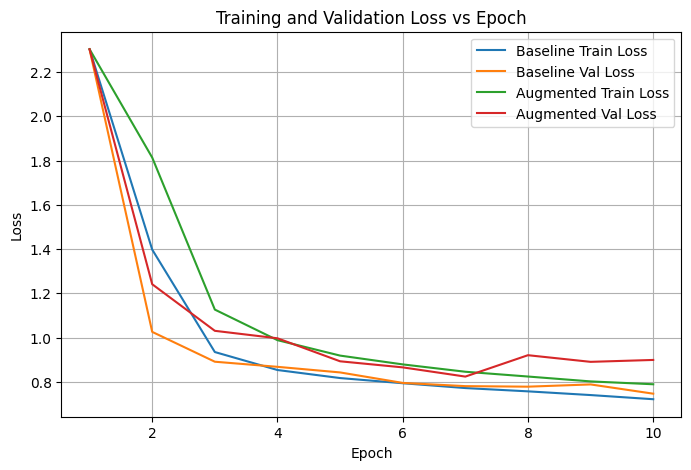

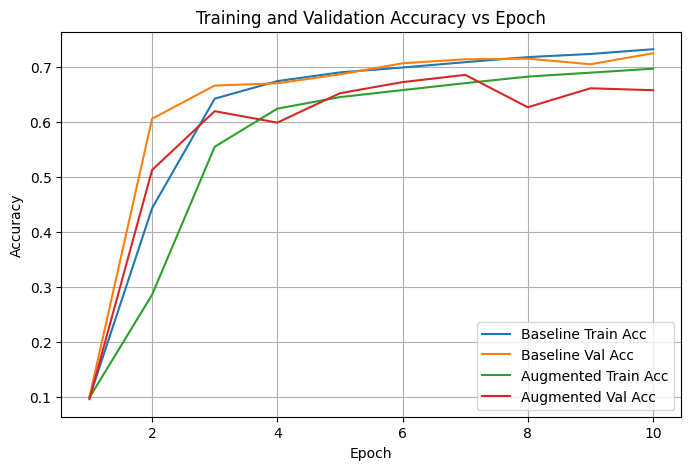


Final Results
------------------------------------------------------------
Experiment 1 — No Data Augmentation
Final Training Accuracy:   0.7321
Final Validation Accuracy: 0.7248
Generalization Gap:        0.0073

Experiment 2 — With Data Augmentation
Final Training Accuracy:   0.6968
Final Validation Accuracy: 0.6576
Generalization Gap:        0.0391

Example prediction
True label: 2 Pullover
Baseline prediction: 2 Pullover
Augmented prediction: 2 Pullover


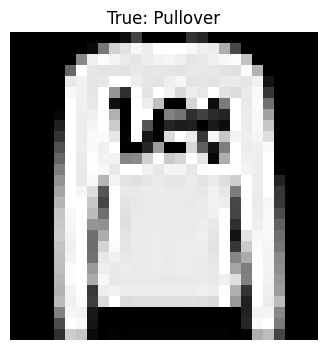

In [32]:
# 11) Plot loss curves
epochs_range = range(1, epochs_cnn + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, baseline_results["train_loss"], label="Baseline Train Loss")
plt.plot(epochs_range, baseline_results["val_loss"], label="Baseline Val Loss")
plt.plot(epochs_range, aug_results["train_loss"], label="Augmented Train Loss")
plt.plot(epochs_range, aug_results["val_loss"], label="Augmented Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# 12) Plot accuracy curves

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, baseline_results["train_acc"], label="Baseline Train Acc")
plt.plot(epochs_range, baseline_results["val_acc"], label="Baseline Val Acc")
plt.plot(epochs_range, aug_results["train_acc"], label="Augmented Train Acc")
plt.plot(epochs_range, aug_results["val_acc"], label="Augmented Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# 13) Report final results
print("\nFinal Results")
print("-" * 60)

print("Experiment 1 — No Data Augmentation")
print(f"Final Training Accuracy:   {baseline_results['final_train_acc']:.4f}")
print(f"Final Validation Accuracy: {baseline_results['final_val_acc']:.4f}")
print(f"Generalization Gap:        {baseline_results['generalization_gap']:.4f}")

print("\nExperiment 2 — With Data Augmentation")
print(f"Final Training Accuracy:   {aug_results['final_train_acc']:.4f}")
print(f"Final Validation Accuracy: {aug_results['final_val_acc']:.4f}")
print(f"Generalization Gap:        {aug_results['generalization_gap']:.4f}")


# 13) Example predictions
sample_index = 1
sample_image = x_test_cnn[sample_index:sample_index+1]
sample_image_raw = x_test[sample_index]
true_label = y_test[sample_index]

baseline_probs = baseline_results["model"](sample_image, training=False).numpy().squeeze()
aug_probs = aug_results["model"](sample_image, training=False).numpy().squeeze()

baseline_pred = np.argmax(baseline_probs)
aug_pred = np.argmax(aug_probs)

print("\nExample prediction")
print("True label:", true_label, class_names[true_label])
print("Baseline prediction:", baseline_pred, class_names[baseline_pred])
print("Augmented prediction:", aug_pred, class_names[aug_pred])

plt.figure(figsize=(4, 4))
plt.imshow(sample_image_raw, cmap="gray")
plt.title(f"True: {class_names[true_label]}")
plt.axis("off")
plt.show()